[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/reinhart-group/generative-copolymer-workshop/blob/main/day3/08_design_challenge.ipynb)

# Day 3, Async: The Design Challenge

Today's topics:
* Choosing a target region in $Z$-space, and why a reachable but non-obvious target is the
  interesting case: one a naive ranking misses but a real search can find.
* Proposing candidate sequences with the EA + GRU surrogate, and the search's optimistic bias.
* **forward-UCB**: a small surrogate ensemble plus an upper-confidence-bound acquisition,
  searching a real pool of already-simulated morphologies one oracle reveal at a time.
* Two named knobs that decide the outcome on a hard target: the explore/exploit weight ($\beta$)
  and the retrain cadence `RETRAIN_EVERY` ($k$), static versus sequential active learning.
* Measuring, on this workshop's own tiny system, how many fewer oracle calls active search needs
  than a random-reveal baseline, and how that connects to notebook 07's evolutionary search.

*Where are we in the pipeline?*

This is the last link: validate.
Everything upstream (simulate, featurize, embed, predict, optimize) already exists.
Today you drive the whole chain yourself, so almost nothing here is new machinery.
This is a lab: guided practice, not new theory.

Real morphologies for every candidate aren't available up front, since those simulations are
exactly what we're trying to avoid running blindly.
forward-UCB trains a small ensemble of surrogates on an upfront pool, scores un-simulated
candidates by predicted proximity to the target and how much the ensemble disagrees, and
oracle-verifies only the top-scoring candidate each round.
An unpublished, instructor-provided preliminary benchmark (Reinhart group, in preparation, 2026,
no DOI, not independently verifiable here) reports it needing on the order of 7-45x fewer total
simulations than a genetic-algorithm search on their systems.
Treat that figure as motivating background, not an established result.
This notebook rebuilds the loop from scratch, on real data, and measures the advantage we can
actually verify here, on our own much smaller system, rather than relying on the unpublished
number.

*What is this notebook, in the pipeline?*

The capstone: almost nothing here is new, since you run the entire workshop end to end, on a
target chosen from the real fitted map.
Day 1 was the simulator: Kremer-Grest MD turns a binary A/B sequence into an aggregate structure
(01/02).
Notebook 03 was the featurizer: a KDE image of that structure through EfficientNet-B0 becomes a
1280-dimensional fingerprint.
Day 2 was the embedder: PCA collapses those fingerprints into a 2-D $Z$-space whose regions are
morphologies (04/05), and a GRU learned to predict a sequence's $Z$-coordinate directly (06).
This morning was the optimizer: an EA searched sequence space using the GRU as a cheap fitness
surrogate, landing on a specific winner, `0110001011` (07).

Each notebook forged one link: simulate, featurize, embed, predict, optimize.
The final link, **validate**, is the one you close today, and not with a single simulation.
`data/exhaustive10` already holds real, completed Kremer-Grest simulations, density images, CNN
features, and descriptors, for all 528 reversal-canonical length-10 sequences.
So the "oracle" this notebook queries is a lookup into real physics, not a stand-in, and the
entire active-learning loop below runs without hoomd, on a laptop, in seconds per round.

## Where this comes from

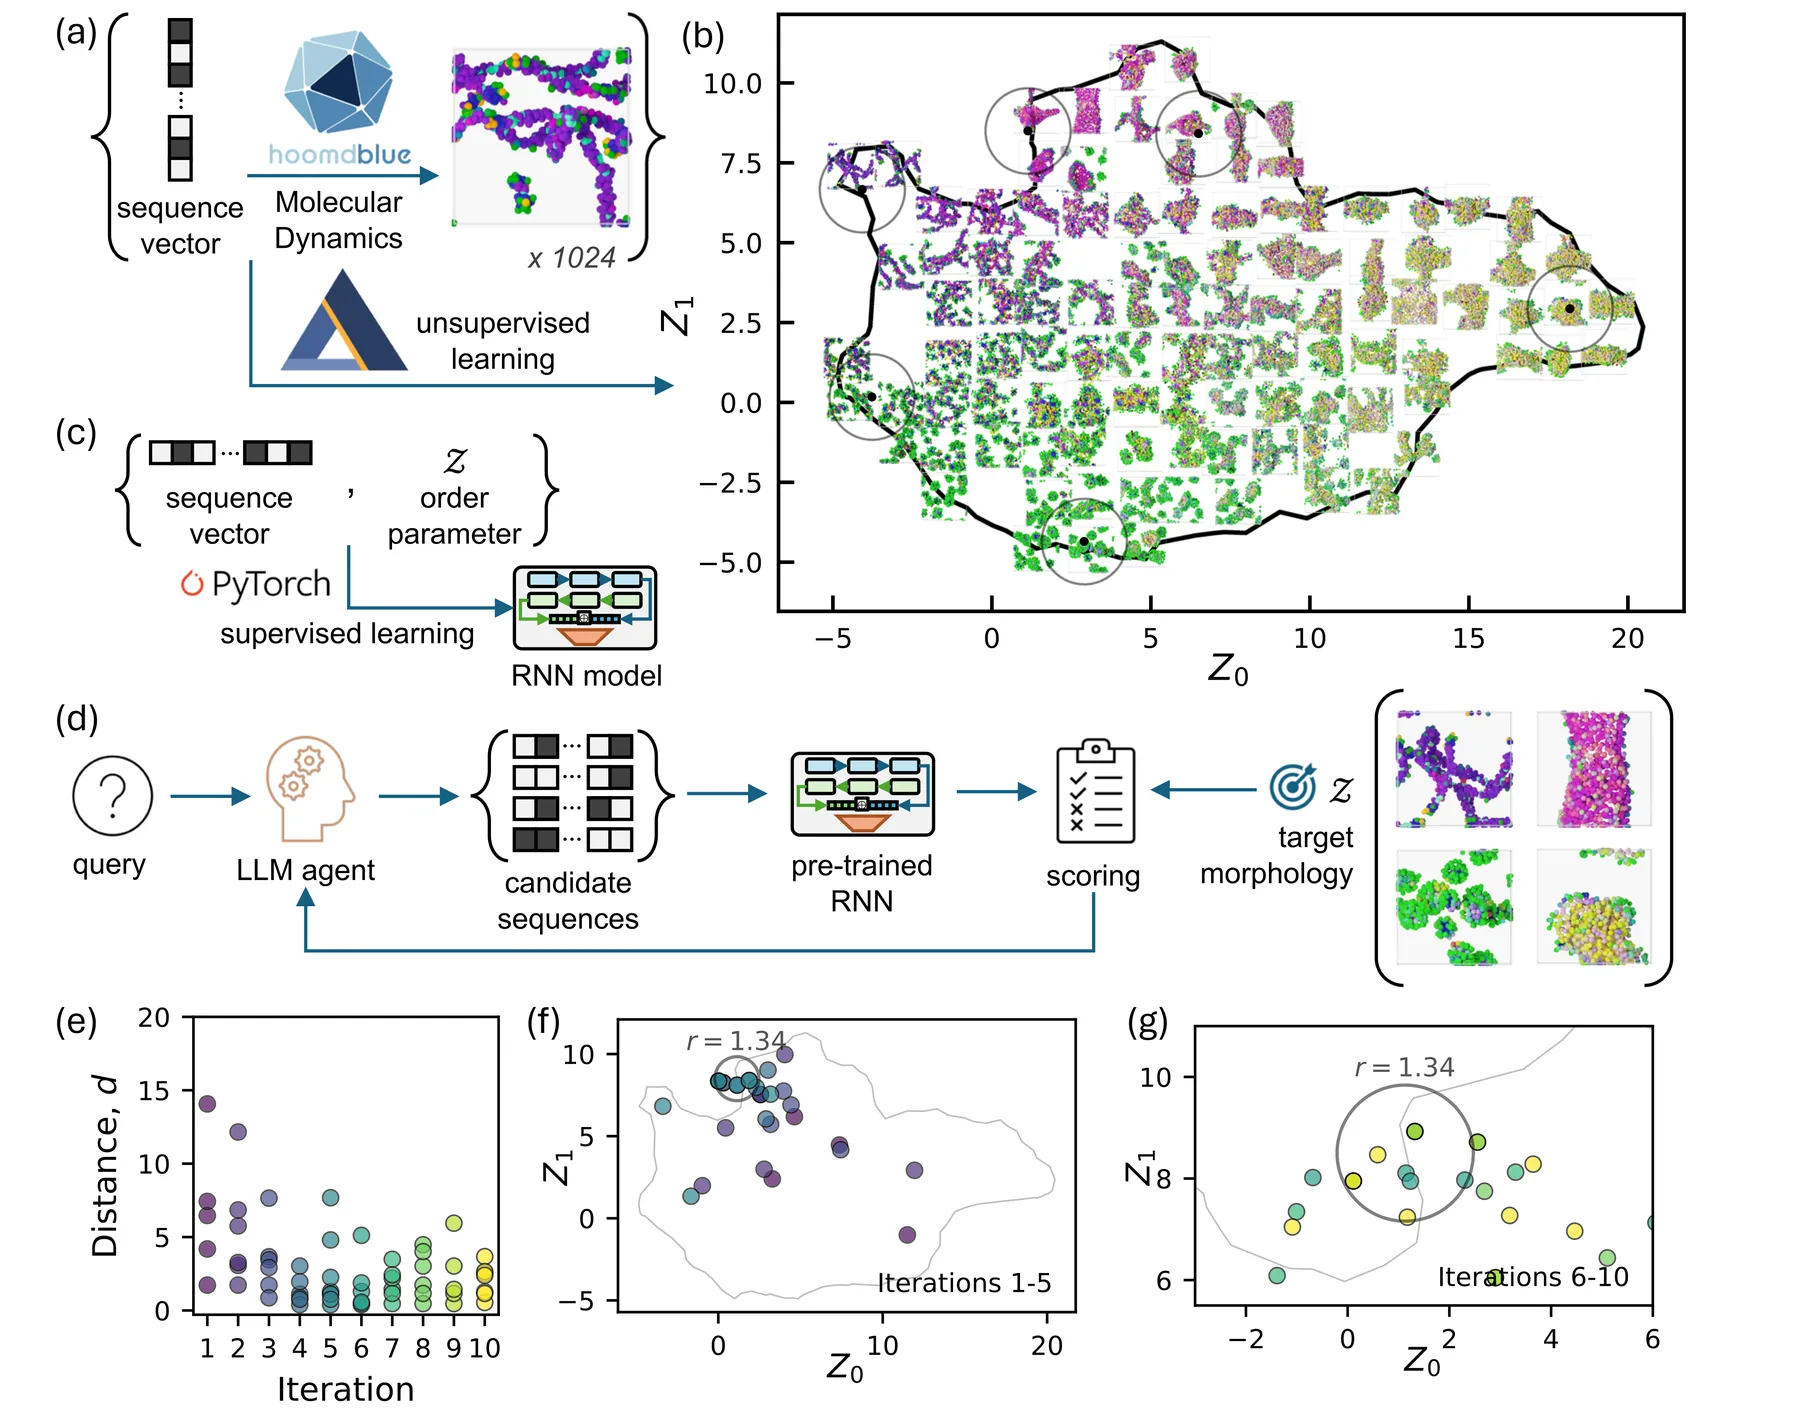

*Fig. 1. Reinhart & Statt, npj Comput. Mater. **10**, 262 (2024). [doi.org/10.1038/s41524-024-01449-6](https://doi.org/10.1038/s41524-024-01449-6)*

The paper closes a design loop: MD builds a morphology map, an RNN scores candidate sequences, and an optimizer proposes the next batch.
Notebook 07 reproduced its classical-EA baseline.

This notebook takes that published loop as its starting point, then asks what happens when the surrogate's favorite candidate is wrong.
You validate candidates against the MD oracle and retrain as new labels accumulate.

You don't run the paper's Claude optimizer or reproduce its comparison.
Forward-UCB is an unpublished extension, tested here on a smaller, precomputed 10-mer library.

This notebook is an outline of the session: the topics above and the published work it builds on.
The complete notebook, with its code and exercises, will be posted before the workshop begins on August 7.